In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report,
                             roc_curve, auc)
from imblearn.over_sampling import SMOTE
from lazypredict.Supervised import LazyClassifier
import pickle


Data loaded and processed successfully!
   gender   age  hypertension  heart_disease  ever_married      work_type  \
0    Male 67.00             0              1             1        Private   
2    Male 80.00             0              1             1        Private   
3  Female 49.00             0              0             1        Private   
4  Female 79.00             1              0             1  Self-employed   
5    Male 81.00             0              0             1        Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69 36.60  formerly smoked       1  
2          Rural             105.92 32.50     never smoked       1  
3          Urban             171.23 34.40           smokes       1  
4          Rural             174.12 24.00     never smoked       1  
5          Urban             186.21 29.00  formerly smoked       1  


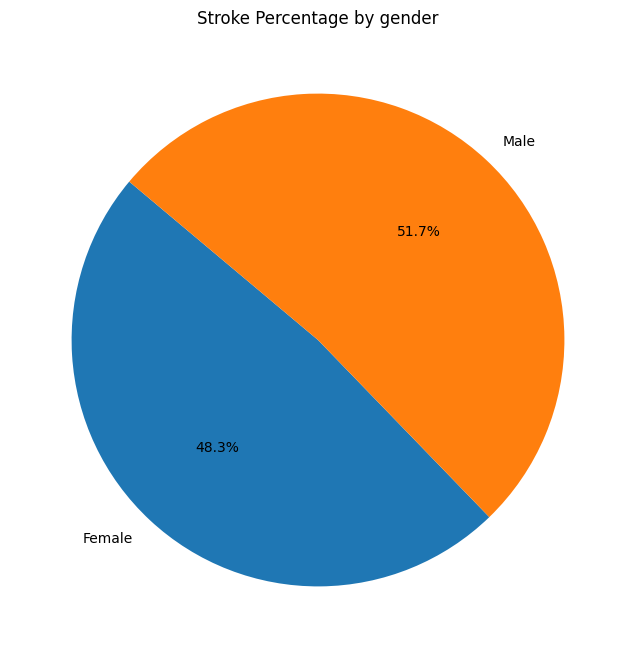

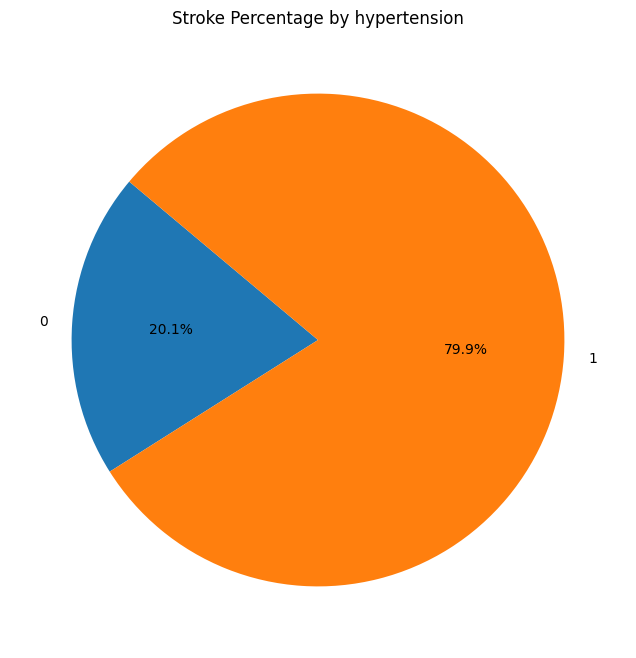

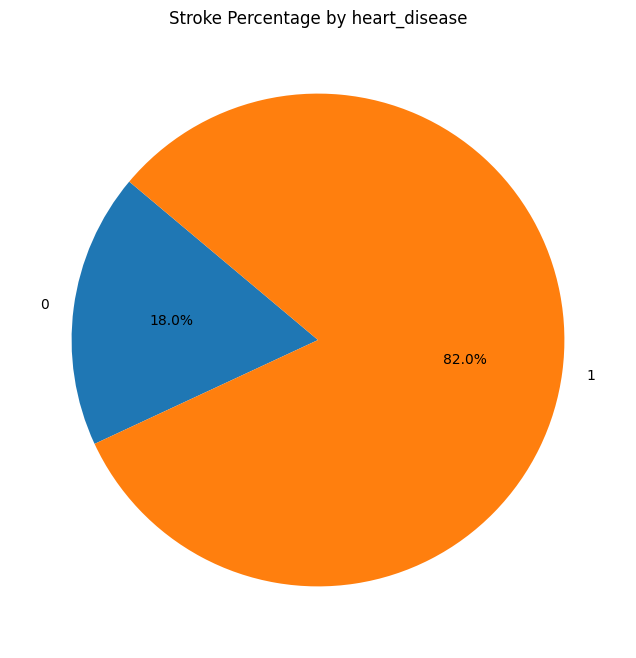

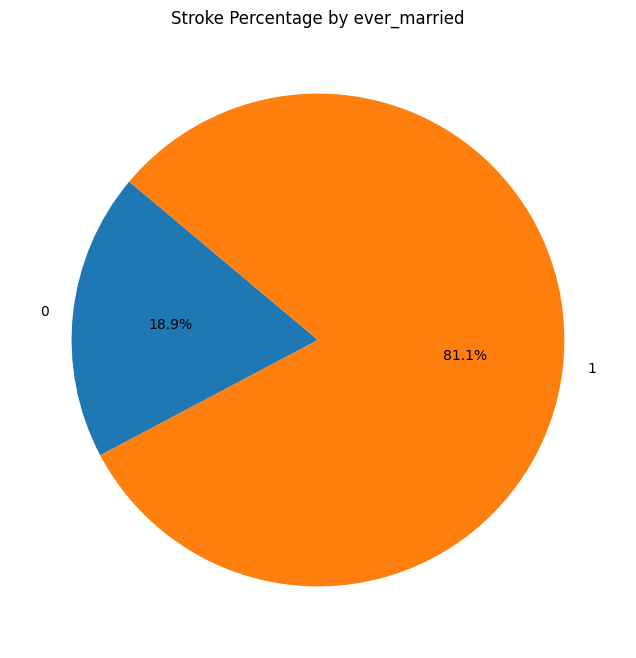

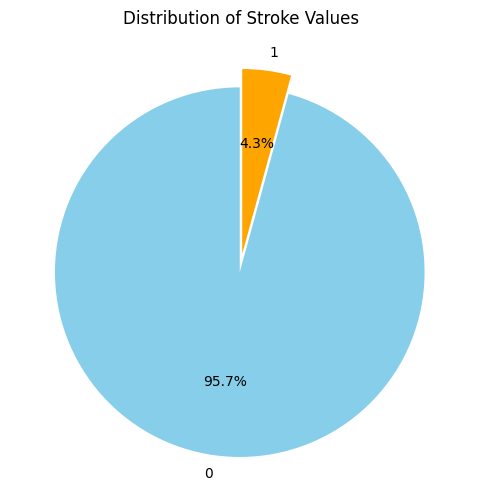

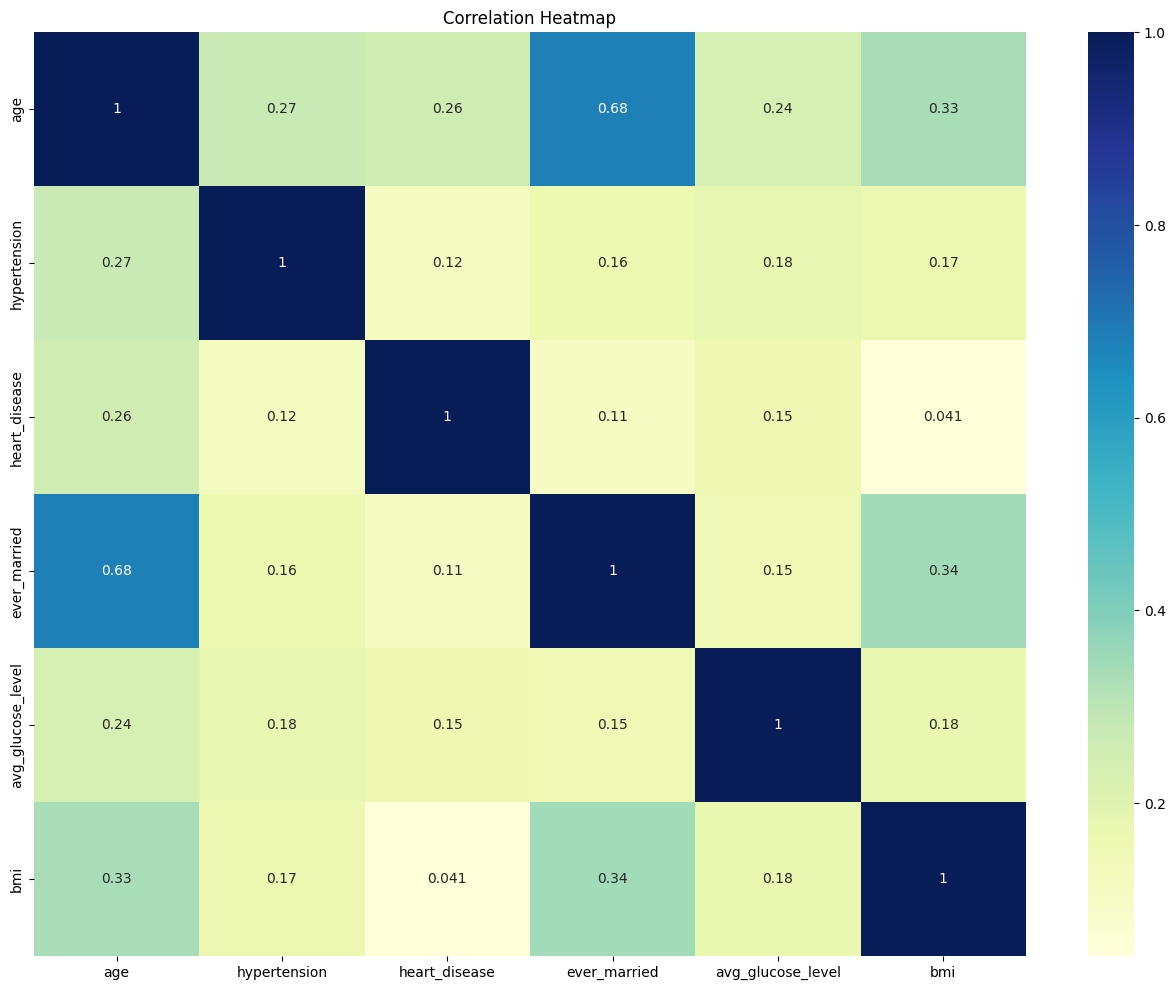

Data balanced with SMOTE. Class distribution:
stroke
1    4699
0    4699
Name: count, dtype: int64


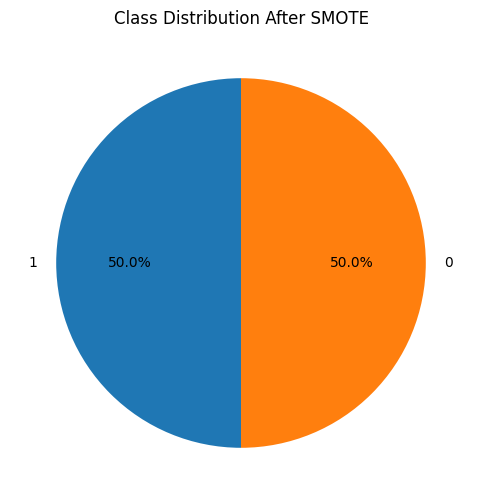

Data split and preprocessed successfully!
X_train shape: (7518, 19), X_test shape: (1880, 19)


100%|██████████| 31/31 [00:10<00:00,  3.01it/s]

[LightGBM] [Info] Number of positive: 3759, number of negative: 3759
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 396
[LightGBM] [Info] Number of data points in the train set: 7518, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Model Comparison using LazyClassifier:
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
RandomForestClassifier             0.97               0.97     0.97      0.97   
LGBMClassifier                     0.97               0.97     0.97      0.97   
ExtraTreesClassifier               0.97               0.97     0.97      0.97   
ExtraTreeClassifier                0.97               0.97     0.97      0.97   
XGBClassifier                      0.97 

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation Accuracy: 0.9748608279894112
Test Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       940
           1       0.98      0.97      0.98       940

    accuracy                           0.98      1880
   macro avg       0.98      0.98      0.98      1880
weighted avg       0.98      0.98      0.98      1880



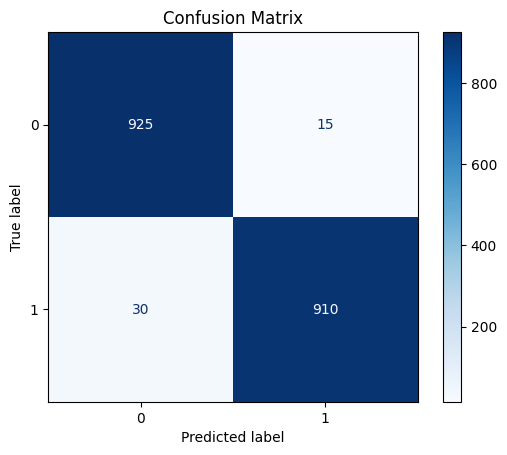

AUC: 1.00


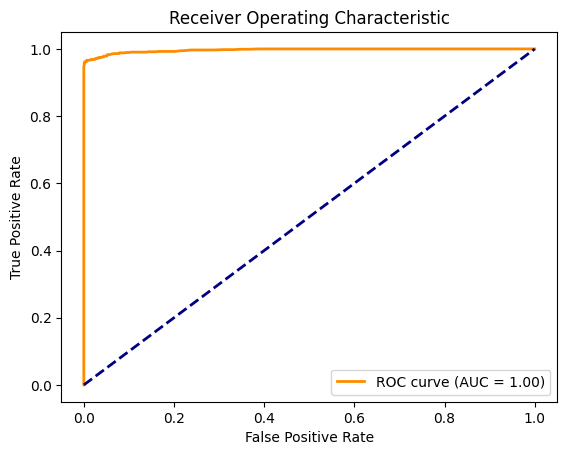

In [11]:
class StrokeAnalysis:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.X_train, self.X_test, self.y_train, self.y_test = None, None, None, None
        self.scaler = StandardScaler()
        
    def load_and_process_data(self):
        "Load and clean the dataset."
        self.df = pd.read_csv(self.file_path)
        self.df = self.df.dropna()
        self.df = self.df.drop("id", axis=1)
        self.df['ever_married'] = self.df['ever_married'].map({'Yes': 1, 'No': 0})
        self.df = self.df[self.df['gender'] != 'Other']
        print("Data loaded and processed successfully!")
        print(self.df.head())
        
    def visualize_data(self):
        "Visualize the distribution of the data."
        # Stroke percentage by various columns
        ColumnsForCountPlot = ['gender', 'hypertension', 'heart_disease', 'ever_married']
        for column in ColumnsForCountPlot:
            stroke_percentages = self.df.groupby(column)['stroke'].mean() * 100
            plt.figure(figsize=(8, 8))
            plt.pie(stroke_percentages, labels=stroke_percentages.index, autopct='%1.1f%%', startangle=140)
            plt.title(f'Stroke Percentage by {column}')
            plt.show()

        # Distribution of stroke
        target_counts = self.df['stroke'].value_counts()
        plt.figure(figsize=(6, 6))
        plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90,
                colors=['skyblue', 'orange'], explode=[0.05] * len(target_counts))
        plt.title('Distribution of Stroke Values')
        plt.show()

        # Heatmap of numerical features
        numeric_df = self.df.drop('stroke', axis=1).select_dtypes(include=['number'])
        corr = numeric_df.corr()
        plt.figure(figsize=(16, 12))
        sns.heatmap(corr, cmap="YlGnBu", annot=True)
        plt.title("Correlation Heatmap")
        plt.show()

    def balance_data_with_smote(self):
        "Balance the dataset using SMOTE."
        X = self.df.drop("stroke", axis=1)
        y = self.df['stroke']
        X = pd.get_dummies(X).astype(int)
        smote = SMOTE(sampling_strategy="minority")
        self.X_smote, self.y_smote = smote.fit_resample(X, y)
        
        print("Data balanced with SMOTE. Class distribution:")
        print(self.y_smote.value_counts())
        
        # Visualize class distribution after SMOTE
        class_counts = self.y_smote.value_counts()
        plt.figure(figsize=(6, 6))
        plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
        plt.title('Class Distribution After SMOTE')
        plt.show()

    def preprocess_and_split(self):
        "Split and preprocess the data."
        # Train-test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X_smote, self.y_smote, test_size=0.2, random_state=42, stratify=self.y_smote
        )

        # Standardize the data
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        # Shuffle the data
        self.X_train, self.y_train = shuffle(self.X_train, self.y_train, random_state=42)
        self.X_test, self.y_test = shuffle(self.X_test, self.y_test, random_state=42)

        print("Data split and preprocessed successfully!")
        print(f"X_train shape: {self.X_train.shape}, X_test shape: {self.X_test.shape}")

    def lazy_classifier_analysis(self):
        "Run LazyClassifier to compare models."
        clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
        models, predictions = clf.fit(self.X_train, self.X_test, self.y_train, self.y_test)
        print("Model Comparison using LazyClassifier:")
        print(models)

    def random_forest_grid_search(self):
        "Perform GridSearchCV on RandomForestClassifier."
        print("Performing Grid Search on RandomForestClassifier...")
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
        rf = RandomForestClassifier(random_state=42)
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1)
        grid_search.fit(self.X_train, self.y_train)
        
        print("Best Parameters:", grid_search.best_params_)
        print("Best Cross-validation Accuracy:", grid_search.best_score_)
        return grid_search.best_estimator_

    def evaluate_model_and_plot_roc(self, model):
        "Evaluate the model and plot ROC curve."
        y_pred = model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        print(f"Test Accuracy: {accuracy:.2f}")
        print("\nClassification Report:\n", classification_report(self.y_test, y_pred))
        
        # Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()

        # ROC Curve
        y_pred_prob = model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(self.y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        print(f"AUC: {roc_auc:.2f}")

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()

# Example Usage
if __name__ == "__main__":
    analysis = StrokeAnalysis("stroke.csv")
    analysis.load_and_process_data()
    analysis.visualize_data()
    analysis.balance_data_with_smote()
    analysis.preprocess_and_split()
    analysis.lazy_classifier_analysis()
    best_model = analysis.random_forest_grid_search()
    analysis.evaluate_model_and_plot_roc(best_model)

    # Save the best model
    with open('stroke.pkl', 'wb') as f:
        pickle.dump(best_model, f)
